# Challenge 3: Artifical Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/LucaPennella/Intro_to_ML_23-24/blob/main/challenges/challenge-three.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


Using Fully Connected Neural Networks and Convolutional Neural Networks, perform the following tasks on FashionMINST.
1. Data exploration.
    * Provide a grid plot of the first 10/12 examples with associated labels
    * Split using the provided pytorch objects into train/validation/test sets
2. For each architecture, tune the number of the hidden layers ($\le 3$), the optimizer, and some hyperparameters of your choice. How many tries to do is up to your discretion. Discuss the choice you made in the report.
3. Summarise your results in a table and comment on them in the report. 
4. For a model (not necessarily the best performing one), plot training loss vs testing loss and training accuracy vs testing accuracy, and comment on what you see.
    * Beyond accuracy provide the confusion matrix for the model outputs. Discuss differences between train/validation/test sets. Is accuracy a good metric in this case why or why not?

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from time import time
import seaborn as sns
import copy
import torch
import torch.nn as nn # basic building blocks for graphs
import torch.nn.functional as F # dropout, loss, activation functions, and more
import torchvision # popular datasets, model architectures, and image transformations for computer vision
import torchvision.transforms as transforms # common image transformations
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets

## Data Download and Augmentation
To improve my model's ability to generalize and to mitigate the slight overfitting I observed, I implemented Data Augmentation. Specifically, I introduced a `RandomHorizontalFlip` (with a 50% probability) and a `RandomRotation` (up to 10 degrees) to artificially increase the diversity of the training images.

A critical aspect of my implementation was preventing data leakage. To ensure that the validation set remained completely untouched by these random transformations, I instantiated the `FashionMNIST` dataset twice: once with the full augmentation pipeline and once with only the base transformations (`ToTensor` and `Normalize`). I then generated a shuffled list of indices and used PyTorch's Subset to assign the training indices to the augmented dataset, and the validation indices to the 'clean' dataset. This guaranteed a strict and reliable evaluation of the model during training.

In [33]:
BATCH_SIZE=64

# Data augmentation
# Transformations for training data
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # 50% chance of flipping the image horizontally
    transforms.RandomRotation(degrees=10), # rotate the image by 10 degrees
    transforms.ToTensor(), # convert the image to a PyTorch tensor
    transforms.Normalize((0.5,), (0.5,)) # normalize the image to have mean 0 and standard deviation 1
])

# No augmentation
# Validation set Transformations
transform_val = transforms.Compose([
        transforms.ToTensor(), # convert the image to a PyTorch tensor
        transforms.Normalize((0.5,), (0.5,)) # normalize the image to have mean 0 and standard deviation 1
])

# downloading the datasets
data_for_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_train)
data_for_val = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_val)

# make index for splitting
num_samples = len(data_for_train)
indices = list(range(num_samples))
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.2 * num_samples)
train_indices, val_indices = indices[split:], indices[:split]

# apply split in Subset
train_data = Subset(data_for_train, train_indices)
val_data = Subset(data_for_val, val_indices)

# make the final test set
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_val)

# make the DataLoder
trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

Training set size: 48000
Validation set size: 12000
Test set size: 10000


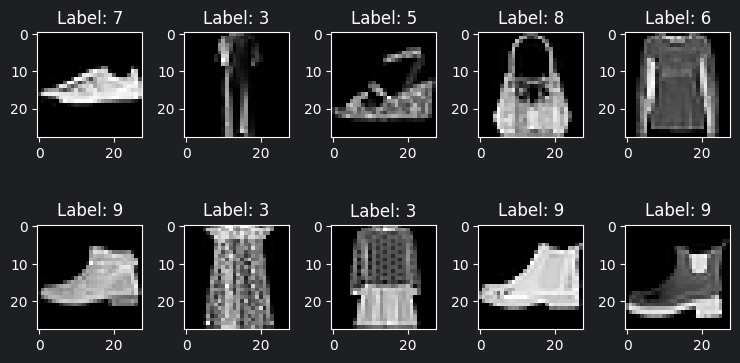

In [34]:
num_row = 2
num_col = 5

fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col, 2*num_row))
for i in range(num_row * num_col):
    ax = axes[i // num_col, i % num_col]
    real_idx = train_data.indices[i]
    ax.imshow(train_data.dataset.data[real_idx].numpy(), cmap='gray')
    ax.set_title('Label: {}'.format(train_data.dataset.targets[real_idx].item()))
plt.tight_layout()
plt.show()

In [35]:
# printing data shapes
print("Single image dimensions:", train_data.dataset.data[0].shape)
for images, labels in trainloader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break

Single image dimensions: torch.Size([28, 28])
Image batch dimensions: torch.Size([64, 1, 28, 28])
Image label dimensions: torch.Size([64])


## Early stop logic
To prevent overfitting and avoid unnecessary computation, I implemented a custom `EarlyStopping` class that monitors the validation loss at the end of each epoch. The class tracks the best validation loss seen so far and increments a counter every time no improvement is observed. If the validation loss fails to decrease by at least `min_delta` for patience consecutive `epochs`, training is halted by breaking out of the loop.

I instantiated it before the training loop with `patience=5` and `min_delta=0.005`, and added just two lines at the end of each epoch — one to call the callback with the current validation loss, and one to check whether to stop. This approach effectively preventing the model from training longer than necessary.

In [36]:
class EarlyStopping:
    """
    Monitor `val_loss` and stop training if it does not improve
    for `patience` consecutive epochs.

    Parameters
    ----------
    patience  : number of epochs to wait before stopping (default 3)
    min_delta : minimum improvement considered a “true improvement” (default 0)
    verbose   : print log messages (default True)
    """
    def __init__(self, patience=3, min_delta=0, verbose=True):
        self.patience  = patience
        self.min_delta = min_delta
        self.verbose   = verbose
        self.best_loss = float('inf')
        self.counter   = 0
        self.stop      = False
        self.best_weights = None  # ← nuovo

    def __call__(self, val_loss, model):  # ← model come parametro aggiuntivo
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())  # ← salva
        else:
            self.counter += 1
            if self.verbose:
                print(f"  ⚠ EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

## Fully-connected NN 1 HL

In [37]:
class MyModel_fc(nn.Module):
    def __init__(self):
        super(MyModel_fc, self).__init__()

        self.l1 = nn.Linear(28 * 28, 128)
        self.l2 = nn.Linear(128, 10)

    def forward(self, x):

        x = x.flatten(start_dim = 1)

        # Activation function
        x = F.relu(x)

        # BSx(32*26*26) => BSx128
        x = self.l1(x)

        x = F.relu(x)

        # BSx128 => BSx10
        logits = self.l2(x)


        return logits


In [38]:
model_fc = MyModel_fc()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_fc = model_fc.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_fc(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")

Output shape is: torch.Size([64, 10])  i.e.: batch_size x num_classes


In [39]:
def get_batch_accuracy(logit, target):
    """Obtain accuracy for one batch of data"""
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects / target.size(0)
    return accuracy.item()

print(f"Accuracy on the single batch just used: {get_batch_accuracy(out, labels)}%")

Accuracy on the single batch just used: 9.375%


In [40]:
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # loss function
optimizer = torch.optim.Adam(model_fc.parameters(), lr=learning_rate)

In [41]:
# lists for saving the training and validation loss and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_fc.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_fc(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_fc.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_fc(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_fc)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 6.53s
Train Loss: 1.2280 | Train Acc: 70.36%
Val Loss:   1.0793 | Val Acc:   75.86%

Epoch 2/50 | Time: 6.00s
Train Loss: 1.0579 | Train Acc: 76.15%
Val Loss:   1.0109 | Val Acc:   78.53%

Epoch 3/50 | Time: 6.14s
Train Loss: 1.0102 | Train Acc: 78.20%
Val Loss:   0.9785 | Val Acc:   79.90%

Epoch 4/50 | Time: 6.09s
Train Loss: 0.9808 | Train Acc: 79.46%
Val Loss:   0.9623 | Val Acc:   80.48%

Epoch 5/50 | Time: 5.86s
Train Loss: 0.9613 | Train Acc: 80.29%
Val Loss:   0.9569 | Val Acc:   80.59%

Epoch 6/50 | Time: 5.88s
Train Loss: 0.9478 | Train Acc: 80.84%
Val Loss:   0.9400 | Val Acc:   81.43%

Epoch 7/50 | Time: 5.82s
Train Loss: 0.9328 | Train Acc: 81.58%
Val Loss:   0.9258 | Val Acc:   81.67%

Epoch 8/50 | Time: 5.96s
Train Loss: 0.9247 | Train Acc: 82.04%
Val Loss:   0.9193 | Val Acc:   82.25%

Epoch 9/50 | Time: 6.13s
Train Loss: 0.9161 | Train Acc: 82.27%
Val Loss:   0.9301 | Val Acc:   81.52%

  ⚠ EarlyStopping: 1/5
Epoch 10/50 | Time: 6.11s
Train Loss: 0.9

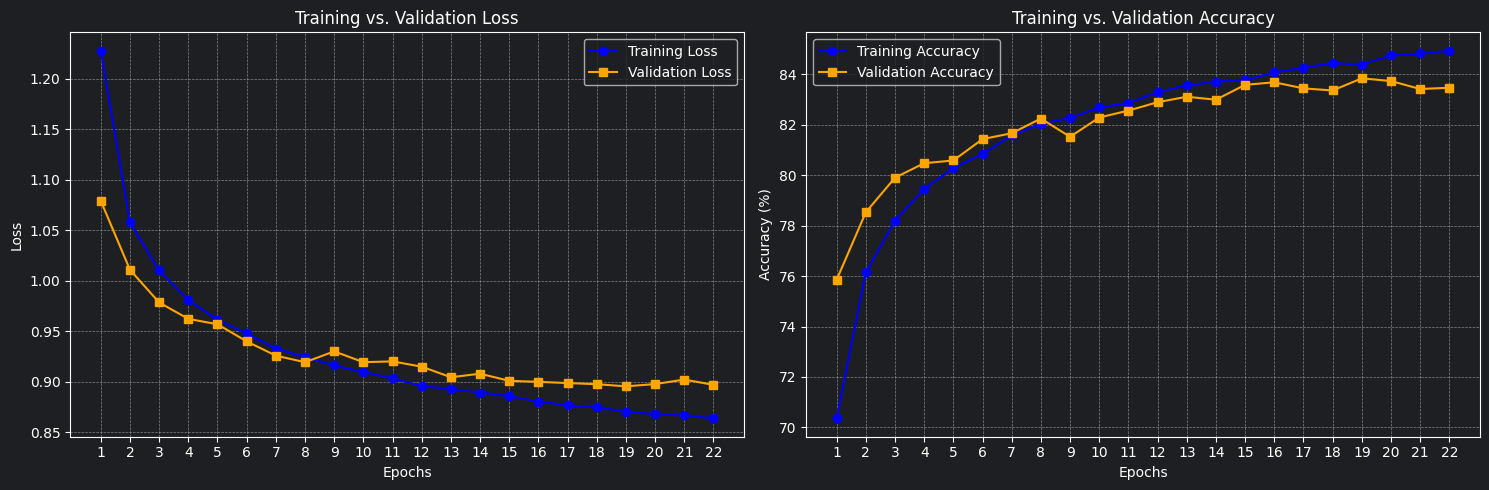

In [43]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The `FC 1HL` model shows a stable and well-behaved training process. Training and validation loss both decrease steadily, while accuracy increases consistently across epochs. The gap between training and validation curves remains small, suggesting limited overfitting and good generalization. Validation performance closely follows training performance, which indicates that the model is learning effectively and reaching a good balance between fit and robustness.

## FCNN with 3 HL
To further optimize the Fully Connected Neural Network and address the overfitting observed in the baseline models, I redesigned the architecture by integrating `Batch Normalization` and `Dropout`.

**First**, I added `Batch Normalization` layers immediately after the linear transformations. **Why?** As the network gets deeper, the distribution of the activations changes constantly during training (a phenomenon known as **internal covariate shift**). **How it works:** `Batch Normalization` standardizes the outputs of each layer for every mini-batch, re-centering and scaling them. This stabilized the learning process, allowed for a **higher learning rate**, and significantly **sped up convergence**.

**Second**, to directly combat overfitting, I implemented `Dropout`. **Why?** The baseline model was beginning to memorize the training data instead of learning generalizable features. **How it works:** By randomly deactivating a specified percentage of neurons (e.g., 30%) during each training pass, `Dropout` prevents neurons from co-adapting too much. It forces the network to learn redundant, robust representations. Naturally, I ensured the model was switched to `.eval()` mode during validation and testing so that all neurons remained active for inference.

In [44]:
class MyModel_fc_3HL(nn.Module):
    def __init__(self):
        super(MyModel_fc_3HL, self).__init__()

        self.fc1 = nn.Linear(784, 512)

        self.bn1 = nn.BatchNorm1d(512)

        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(512, 256)

        self.bn2 = nn.BatchNorm1d(256)

        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(256, 128)

        self.bn3 = nn.BatchNorm1d(128)

        self.drop3 = nn.Dropout(0.2)

        self.out = nn.Linear(128, 10)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn2(self.fc2(x))))
        x = self.drop3(F.relu(self.bn3(self.fc3(x))))
        logits = self.out(x)
        return logits

## ADAM FC 3HL

In [45]:
model_fc_3h = MyModel_fc_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_fc_3h = model_fc_3h.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_fc_3h(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [46]:
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # loss function, to prevent overfitting
optimizer_adam = torch.optim.Adam(model_fc_3h.parameters(), lr=learning_rate, weight_decay=1e-4)

In [47]:
# lists for saving the training and validation loss and accuracy
train_losses_adam3 = []
val_losses_adam3 = []
train_accuracies_adam3 = []
val_accuracies_adam3 = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_fc_3h.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_fc_3h(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_adam.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_adam.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_adam3.append(avg_train_loss)
    train_accuracies_adam3.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_fc_3h.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_fc_3h(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_adam3.append(avg_val_loss)
    val_accuracies_adam3.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_fc_3h)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 8.24s
Train Loss: 1.0123 | Train Acc: 77.76%
Val Loss:   0.8818 | Val Acc:   82.46%

Epoch 2/50 | Time: 7.08s
Train Loss: 0.9116 | Train Acc: 81.78%
Val Loss:   0.8331 | Val Acc:   84.77%

Epoch 3/50 | Time: 6.74s
Train Loss: 0.8846 | Train Acc: 82.85%
Val Loss:   0.8091 | Val Acc:   85.57%

Epoch 4/50 | Time: 6.60s
Train Loss: 0.8723 | Train Acc: 83.38%
Val Loss:   0.8117 | Val Acc:   85.61%

  ⚠ EarlyStopping: 1/5
Epoch 5/50 | Time: 6.41s
Train Loss: 0.8574 | Train Acc: 84.24%
Val Loss:   0.7935 | Val Acc:   86.39%

Epoch 6/50 | Time: 6.45s
Train Loss: 0.8510 | Train Acc: 84.42%
Val Loss:   0.7907 | Val Acc:   86.44%

  ⚠ EarlyStopping: 1/5
Epoch 7/50 | Time: 6.48s
Train Loss: 0.8433 | Train Acc: 84.72%
Val Loss:   0.7911 | Val Acc:   86.44%

  ⚠ EarlyStopping: 2/5
Epoch 8/50 | Time: 6.46s
Train Loss: 0.8410 | Train Acc: 84.89%
Val Loss:   0.7830 | Val Acc:   87.07%

Epoch 9/50 | Time: 6.51s
Train Loss: 0.8368 | Train Acc: 85.20%
Val Loss:   0.7824 | Val Acc:   87.

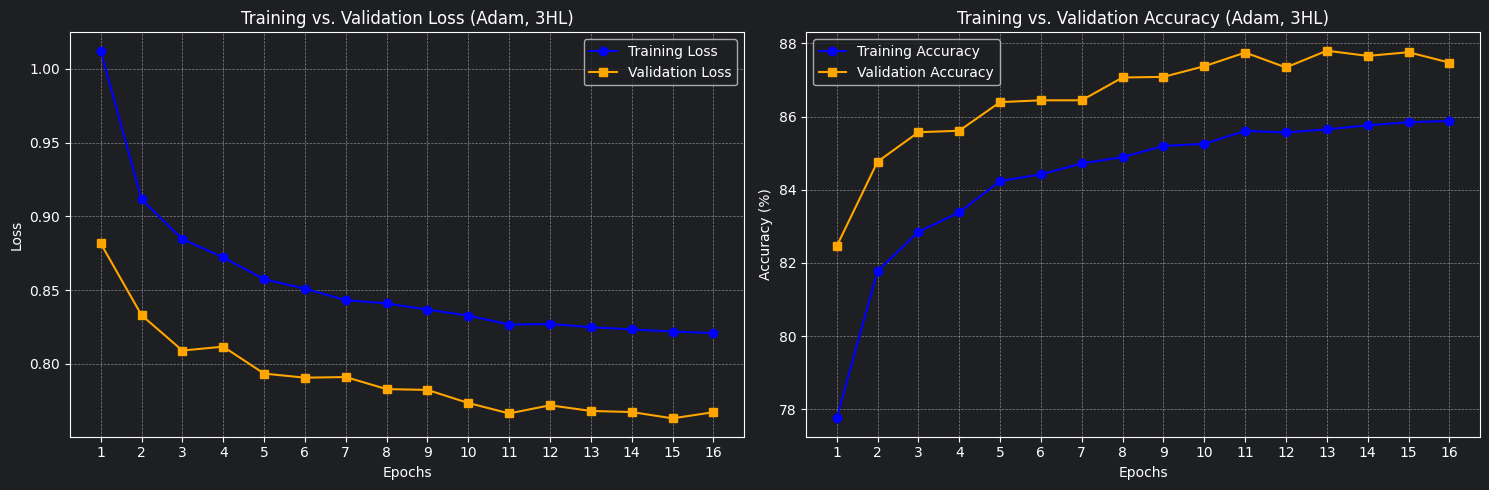

In [49]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_adam3) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_adam3, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_adam3, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (Adam, 3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_adam3, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_adam3, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (Adam, 3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The Adam model with 3 hidden layers shows a faster and stronger learning trend than the FC 1HL model. Both training and validation loss decrease steadily, and validation loss remains consistently below training loss, which suggests good generalization rather than overfitting. Accuracy also improves quickly and reaches a higher plateau, with validation accuracy slightly outperforming training accuracy throughout most of the training. Overall, this configuration appears more effective and more stable, achieving better performance with a clear balance between training fit and validation results.

## SGD FC 3HL
The `SGD` optimizer was combined with a learning rate scheduler to improve convergence over time. The scheduler gradually reduced the learning rate during training, allowing larger parameter updates in the early stages and finer refinements later on. This made the optimization process more stable and helped the model approach a better minimum. In addition, `momentum` was used to accelerate learning by smoothing updates across iterations and reducing oscillations, while `Nesterov momentum` provided a more anticipatory update by evaluating the gradient after the momentum step. Together, these techniques helped `SGD` converge faster and more reliably.

In [50]:
model_fc_3h_s = MyModel_fc_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_fc_3h_s = model_fc_3h_s.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_fc_3h_s(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")
# Number of times the whole (training) dataset is used for training
num_epochs = 50

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # loss function, to prevent overfitting
optimizer_sgd = torch.optim.SGD(model_fc_3h_s.parameters(), lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4) # nesterov looks forward
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_sgd, mode='min', factor=0.1, patience=3)

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [51]:
# lists for saving the training and validation loss and accuracy
train_losses_sgd3 = []
val_losses_sgd3 = []
train_accuracies_sgd3 = []
val_accuracies_sgd3 = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_fc_3h_s.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_fc_3h_s(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_sgd.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_sgd.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_sgd3.append(avg_train_loss)
    train_accuracies_sgd3.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_fc_3h_s.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_fc_3h_s(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_sgd3.append(avg_val_loss)
    val_accuracies_sgd3.append(avg_val_acc)

    scheduler.step(avg_val_loss)
    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_fc_3h_s)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 6.88s
Train Loss: 1.0422 | Train Acc: 76.60%
Val Loss:   0.8609 | Val Acc:   83.67%

Epoch 2/50 | Time: 8.54s
Train Loss: 0.9259 | Train Acc: 81.73%
Val Loss:   0.8473 | Val Acc:   83.74%

Epoch 3/50 | Time: 7.78s
Train Loss: 0.8993 | Train Acc: 82.65%
Val Loss:   0.8093 | Val Acc:   86.13%

Epoch 4/50 | Time: 6.29s
Train Loss: 0.8799 | Train Acc: 83.49%
Val Loss:   0.8011 | Val Acc:   86.33%

Epoch 5/50 | Time: 6.53s
Train Loss: 0.8654 | Train Acc: 84.10%
Val Loss:   0.7918 | Val Acc:   86.84%

Epoch 6/50 | Time: 6.55s
Train Loss: 0.8522 | Train Acc: 84.83%
Val Loss:   0.7938 | Val Acc:   86.63%

  ⚠ EarlyStopping: 1/5
Epoch 7/50 | Time: 6.67s
Train Loss: 0.8493 | Train Acc: 84.86%
Val Loss:   0.7821 | Val Acc:   87.00%

Epoch 8/50 | Time: 6.33s
Train Loss: 0.8385 | Train Acc: 85.31%
Val Loss:   0.7810 | Val Acc:   87.31%

  ⚠ EarlyStopping: 1/5
Epoch 9/50 | Time: 6.31s
Train Loss: 0.8300 | Train Acc: 85.70%
Val Loss:   0.7697 | Val Acc:   87.85%

Epoch 10/50 | Time

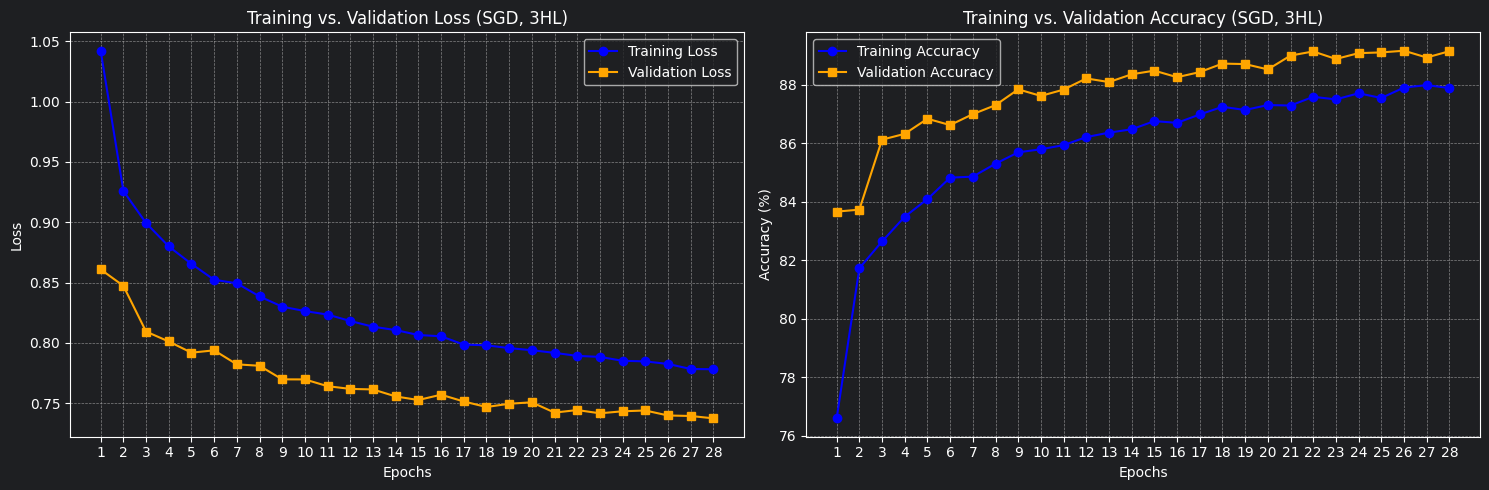

In [52]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_sgd3) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_sgd3, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_sgd3, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (SGD, 3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_sgd3, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_sgd3, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (SGD, 3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The `SGD` model with 3 hidden layers shows a strong and consistent training behavior. Both training and validation loss decrease steadily across epochs, and the validation loss remains slightly below the training loss, which suggests good generalization and no clear signs of overfitting. Accuracy also improves gradually and reaches a high plateau, with validation accuracy consistently slightly higher than training accuracy. Overall, this configuration appears stable and effective, and the use of `SGD` with `momentum`, `Nesterov` acceleration, and a learning rate `scheduler` likely contributed to the smooth convergence.

## ADAMW FC 3HL
To further optimize the network and ensure robust generalization, I decided to test the `AdamW` optimizer alongside the standard `Adam`. The primary motivation stems from a known flaw in how standard Adam handles weight decay. In traditional `SGD`, weight decay and **L2 regularization** are mathematically equivalent. However, in adaptive optimizers like `Adam`, this equivalence breaks down. Standard `Adam` implements weight decay by adding the **L2 penalty directly to the loss function**. Because `Adam` adaptively scales the update steps based on the historical variance of the gradients, it inadvertently **scales down the L2 penalty** as well—essentially 'eating' the regularization effect for weights with large gradients. `AdamW` solves this by **decoupling the weight decay from the gradient update**, applying the decay directly to the weights instead. This allows the model to benefit from `Adam`'s fast convergence while properly regularizing the network to prevent overfitting.

In [53]:
model_fc_3h_a = MyModel_fc_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_fc_3h_a = model_fc_3h_a.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_fc_3h_a(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")
# Number of times the whole (training) dataset is used for training
num_epochs = 50

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # loss function, to prevent overfitting
optimizer_AdamW = torch.optim.AdamW(model_fc_3h_a.parameters(), lr=0.001, weight_decay=1e-4)

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [54]:
# lists for saving the training and validation loss and accuracy
train_losses_adamw3 = []
val_losses_adamw3 = []
train_accuracies_adamw3 = []
val_accuracies_adamw3 = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_fc_3h_a.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_fc_3h_a(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_AdamW.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_AdamW.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_adamw3.append(avg_train_loss)
    train_accuracies_adamw3.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_fc_3h_a.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_fc_3h_a(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_adamw3.append(avg_val_loss)
    val_accuracies_adamw3.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_fc_3h_a)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 7.03s
Train Loss: 1.0124 | Train Acc: 77.78%
Val Loss:   0.8519 | Val Acc:   83.44%

Epoch 2/50 | Time: 8.74s
Train Loss: 0.9073 | Train Acc: 82.31%
Val Loss:   0.8209 | Val Acc:   85.06%

Epoch 3/50 | Time: 7.84s
Train Loss: 0.8825 | Train Acc: 83.11%
Val Loss:   0.8010 | Val Acc:   86.26%

Epoch 4/50 | Time: 6.48s
Train Loss: 0.8621 | Train Acc: 83.93%
Val Loss:   0.7896 | Val Acc:   86.74%

Epoch 5/50 | Time: 6.53s
Train Loss: 0.8537 | Train Acc: 84.31%
Val Loss:   0.7885 | Val Acc:   86.98%

  ⚠ EarlyStopping: 1/5
Epoch 6/50 | Time: 6.51s
Train Loss: 0.8390 | Train Acc: 85.07%
Val Loss:   0.7849 | Val Acc:   86.72%

  ⚠ EarlyStopping: 2/5
Epoch 7/50 | Time: 6.49s
Train Loss: 0.8302 | Train Acc: 85.51%
Val Loss:   0.7782 | Val Acc:   87.03%

Epoch 8/50 | Time: 6.53s
Train Loss: 0.8235 | Train Acc: 85.78%
Val Loss:   0.7638 | Val Acc:   87.65%

Epoch 9/50 | Time: 6.39s
Train Loss: 0.8199 | Train Acc: 85.82%
Val Loss:   0.7782 | Val Acc:   87.13%

  ⚠ EarlyStopping:

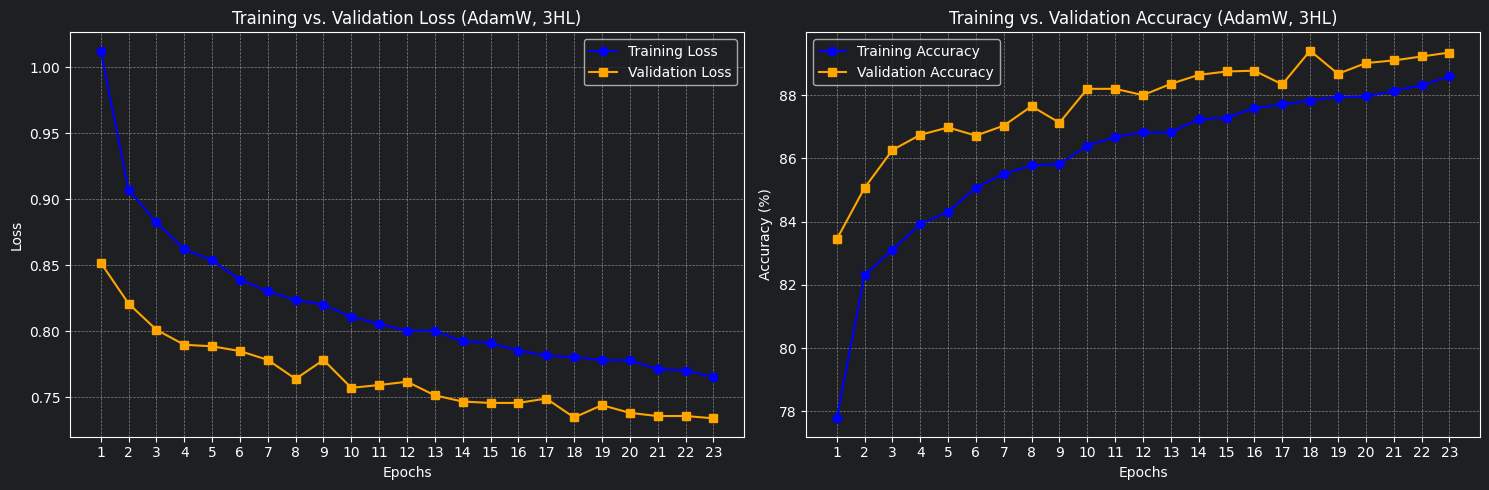

In [55]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_adamw3) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_adamw3, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_adamw3, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (AdamW, 3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_adamw3, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_adamw3, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (AdamW, 3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Analyzing the learning curves for my 3-Hidden Layer Fully Connected model optimized with `AdamW`, we can observe a very positive training dynamic over the 23 epochs. Both training and validation losses decrease steadily, while accuracies increase, indicating that the network is learning effectively. At first glance, it might seem unusual that the validation loss is consistently lower than the training loss (and conversely, the validation accuracy is higher). However, this is the expected behavior given the strong regularization I applied. During the training phase, the model's performance is artificially hindered by `Dropout` (which deactivates a portion of the neurons) and `Data Augmentation` (which makes the input images harder to classify). During the validation phase, the model is switched to `.eval()` mode—meaning `Dropout` is disabled and it uses its full capacity on clean, unaugmented images. Overall, the curves show no signs of overfitting, proving that the `AdamW` optimizer combined with these regularization techniques led to a highly robust model, achieving a final validation accuracy of approximately `89.35%`.

## Test

In [78]:
models_to_test = {
    "Fully Connected 3HL (AdamW)": model_fc_3h_a,
    "Fully Connected 3HL (SGD)": model_fc_3h_s,
    "Fully Connected 3HL (Adam)": model_fc_3h,
    "Fully Connected 1HL (Adam)": model_fc
}

print("=========================================")
print("  Starting test set visualization...     ")
print("=========================================\n")


for nome, modello in models_to_test.items():


    modello = modello.to(device)


    modello.eval()

    test_running_loss = 0.0
    test_acc = 0.0


    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)


            logits = modello(images)
            loss = criterion(logits, labels)

            test_running_loss += loss.item()
            test_acc += get_batch_accuracy(logits, labels)


    avg_test_loss = test_running_loss / len(testloader)
    avg_test_acc = test_acc / len(testloader)


    print(f"Model: {nome}")
    print(f" -> Test Loss: {avg_test_loss:.4f} | Test Accuracy: {avg_test_acc:.2f}%\n")
    print("-" * 41)

  Starting test set visualization...     

Model: Fully Connected 3HL (AdamW)
 -> Test Loss: 0.7460 | Test Accuracy: 88.54%

-----------------------------------------
Model: Fully Connected 3HL (SGD)
 -> Test Loss: 0.7507 | Test Accuracy: 88.59%

-----------------------------------------
Model: Fully Connected 3HL (Adam)
 -> Test Loss: 0.7820 | Test Accuracy: 86.99%

-----------------------------------------
Model: Fully Connected 1HL (Adam)
 -> Test Loss: 0.9102 | Test Accuracy: 82.85%

-----------------------------------------


The final evaluation on the test set provides clear insights into how both architectural depth and the choice of optimizer affect the model's ability to generalize on unseen data.

First, analyzing the architectural capacity, the baseline `Fully Connected 1HL (Adam)` model severely underperformed, achieving only `82.85%` accuracy and the highest test loss (`0.9102`). This confirms that a single hidden layer lacks the representational power needed to capture the complex, non-linear visual patterns of the `FashionMNIST` dataset. By upgrading to a deeper architecture, the `Fully Connected 3HL (Adam)` provided a massive jump in performance, reaching `86.99%` accuracy.

However, the most crucial finding comes from comparing the optimization strategies on the 3HL architecture. While standard `Adam` reached `~87%`, it was clearly outclassed by both `SGD` and `AdamW`. The `SGD` model (equipped with `Nesterov` momentum) achieved the **highest overall accuracy** at `88.59%`, confirming its known ability to find flatter, more generalizable minima. Meanwhile, `AdamW` performed practically on par with `SGD` (`88.54%` accuracy) but achieved the **absolute lowest test loss** of all models (`0.7460`). This perfectly validates my previous hypothesis: standard `Adam` struggled to generalize because its adaptive gradients 'eat' the `L2` penalty, whereas `AdamW`'s decoupled weight decay successfully regularized the network, matching the strong generalization of `SGD`.

## Confusion Matrix

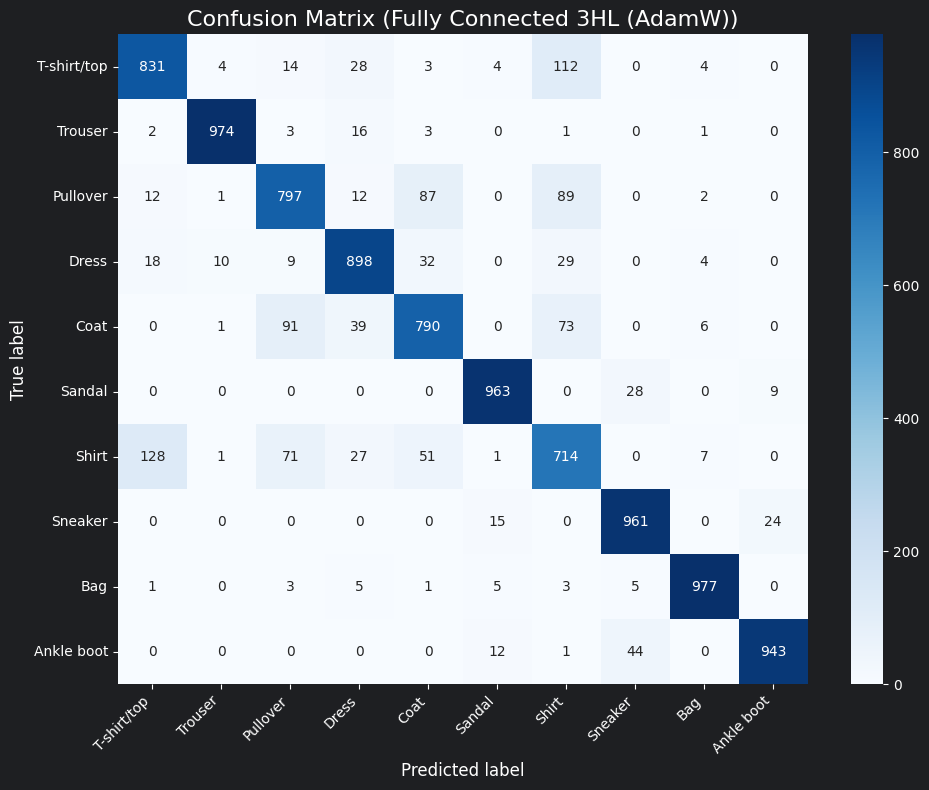

In [57]:
model_matrix_f = model_fc_3h_a
model_matrix_f = model_matrix_f.to(device)
model_matrix_f.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_matrix_f(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cm = confusion_matrix(all_targets, all_preds, labels=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix (Fully Connected 3HL (AdamW))', fontsize=16)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Comments on Confusion Matrix
The confusion matrix for my 3-Hidden Layer model optimized with `AdamW` provides a transparent breakdown of the network's classification performance. Looking at the strong dark-blue diagonal, it is clear that the model is highly confident and accurate when classifying visually distinct categories. Specifically, items like `Trousers` (974), `Bags` (977), and all types of footwear (`Sandals`, `Sneakers`, and `Ankle boots`, all scoring over 940) are classified with near-perfect accuracy.

However, analyzing the off-diagonal cells reveals a very specific cluster of errors: the model struggles significantly to differentiate between various upper-body garments. The most problematic class is the `Shirt`, which is frequently misclassified as a `T-shirt/top` (128 times), a `Pullover` (71 times), or a `Coat` (51 times). Similarly, `Pullovers` and `Coats` are often mistaken for one another. This behavior is completely understandable and expected. In the low-resolution, `28x28` grayscale images of the `FashionMNIST` dataset, the basic silhouettes of `shirts`, `t-shirts`, and `coats` are incredibly similar. Since a Fully Connected network flattens the image and loses spatial hierarchies, it naturally struggles to find the fine-grained textural differences needed to separate these overlapping classes.

## CNN

In [58]:
class MyModel_c(nn.Module):
    def __init__(self):
        super(MyModel_c, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.l1 = nn.Linear(32 * 26 * 26, 128)
        self.l2 = nn.Linear(128, 10)

    def forward(self, x):
        # Convolution: BSx1x28x28 => BSx32x26x26
        x = self.conv1(x)

        # Activation function
        x = F.relu(x)

        # flatten => BS x (32*26*26) = BS x 21632
        x = x.flatten(start_dim = 1)

        # BSx(32*26*26) => BSx128
        x = self.l1(x)

        x = F.relu(x)

        # BSx128 => BSx10
        logits = self.l2(x)


        return logits


In [59]:
model_c = MyModel_c()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_c = model_c.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_c(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")

Output shape is: torch.Size([16, 10])  i.e.: batch_size x num_classes


In [60]:
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # loss function
optimizer_adam_c = torch.optim.Adam(model_c.parameters(), lr=learning_rate, weight_decay=1e-4)

In [61]:
# lists for saving the training and validation loss and accuracy
train_losses_adamc = []
val_losses_adamc = []
train_accuracies_adamc = []
val_accuracies_adamc = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_c.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_c(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_adam_c.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_adam_c.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_adamc.append(avg_train_loss)
    train_accuracies_adamc.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_c.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_c(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_adamc.append(avg_val_loss)
    val_accuracies_adamc.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_c)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 6.96s
Train Loss: 0.9421 | Train Acc: 81.05%
Val Loss:   0.8378 | Val Acc:   85.49%

Epoch 2/50 | Time: 8.50s
Train Loss: 0.8121 | Train Acc: 86.85%
Val Loss:   0.7722 | Val Acc:   88.43%

Epoch 3/50 | Time: 8.47s
Train Loss: 0.7848 | Train Acc: 88.03%
Val Loss:   0.7637 | Val Acc:   88.87%

Epoch 4/50 | Time: 6.42s
Train Loss: 0.7686 | Train Acc: 88.67%
Val Loss:   0.7568 | Val Acc:   89.10%

Epoch 5/50 | Time: 6.55s
Train Loss: 0.7569 | Train Acc: 89.30%
Val Loss:   0.7553 | Val Acc:   89.39%

  ⚠ EarlyStopping: 1/5
Epoch 6/50 | Time: 6.54s
Train Loss: 0.7508 | Train Acc: 89.57%
Val Loss:   0.7428 | Val Acc:   89.62%

Epoch 7/50 | Time: 6.44s
Train Loss: 0.7444 | Train Acc: 89.94%
Val Loss:   0.7386 | Val Acc:   89.89%

  ⚠ EarlyStopping: 1/5
Epoch 8/50 | Time: 6.64s
Train Loss: 0.7391 | Train Acc: 90.16%
Val Loss:   0.7448 | Val Acc:   89.78%

  ⚠ EarlyStopping: 2/5
Epoch 9/50 | Time: 6.50s
Train Loss: 0.7367 | Train Acc: 90.15%
Val Loss:   0.7370 | Val Acc:   90.

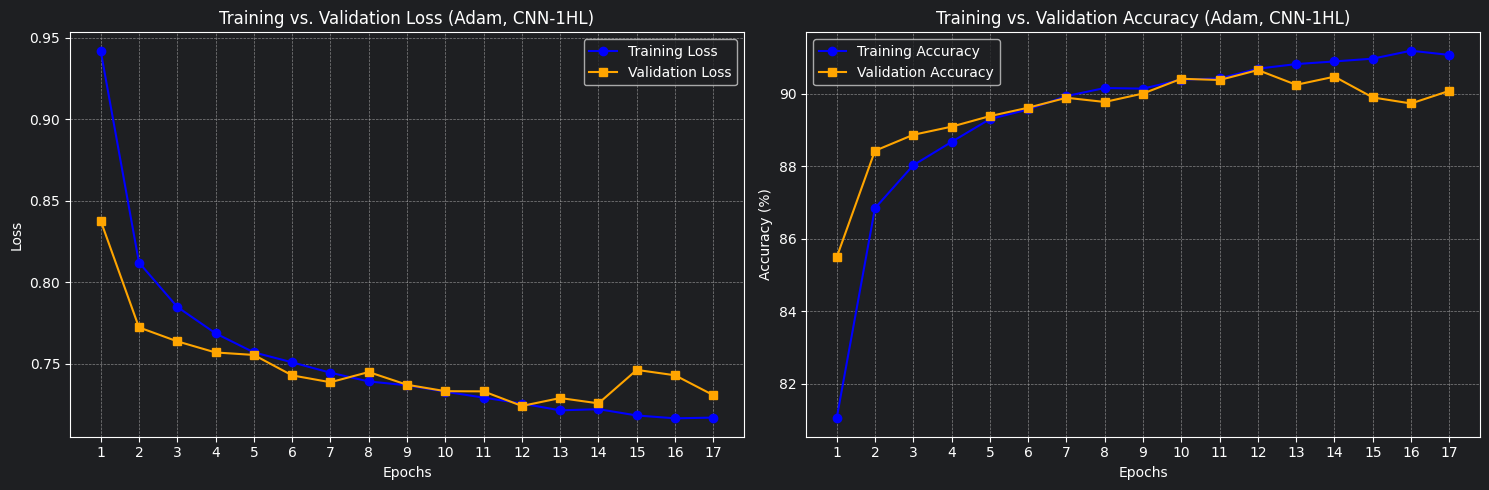

In [62]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_adamc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_adamc, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_adamc, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (Adam, CNN-1HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_adamc, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_adamc, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (Adam, CNN-1HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Moving from a Fully Connected architecture to a Convolutional Neural Network (CNN-1HL) optimized with standard `Adam`, the learning curves reveal a significant leap in performance. In the first 11 epochs, the model learns rapidly and efficiently. Similar to previous runs, the validation loss starts lower than the training loss, confirming that our regularization techniques (`Dropout` and `Data Augmentation`) are actively challenging the network during training, while allowing it to perform at full capacity during validation. By epoch 12, the model hits a peak validation accuracy of roughly `90.5%`—noticeably outperforming the best 3HL Fully Connected models. This confirms my hypothesis: by utilizing convolutional layers, the network successfully preserves 2D spatial context (like edges and shapes) rather than flattening the image and losing crucial structural information.

However, observing the latter part of the training (epochs 14 to 17), a clear divergence emerges. While the training loss continues its downward trajectory, the validation loss abruptly spikes upward, and validation accuracy begins to dip. This is a textbook example of the onset of overfitting.

## CNN with 3HL
To overcome the spatial limitations of Fully Connected networks, I designed a Convolutional Neural Network (CNN) featuring 3 convolutional blocks. The core idea behind this architecture is to progressively extract increasingly complex spatial hierarchies.

**How it is structured:** The network consists of three sequential blocks. Each block applies a `Conv2d` layer with a $3x3$ kernel and `padding` of $1$ to preserve spatial dimensions, followed by `BatchNorm2d`, a `ReLU` activation, and a `MaxPool2d` layer. As the network deepens, I progressively doubled the number of feature channels ($32$ $\rightarrow$ $64$ $\rightarrow$ $128$) while the MaxPooling layers halved the spatial dimensions of the image at each step (shrinking the $28x28$ input down to $14x14$, then $7x7$, and finally $3x3$ due to integer division).
The resulting $3x3$ feature maps across $128$ channels are then flattened into a `1D tensor` of $1152$ elements, which feeds into a Fully Connected layer of $256$ units before the final 10-class output.

**Why these specific choices:** To ensure training stability and prevent overfitting, I implemented a robust, multi-stage regularization strategy. `I used Batch Normalization` in every convolutional block to reduce internal covariate shift and accelerate convergence.
Crucially, instead of standard `Dropout`, I applied `Dropout2d` (with increasing rates: $0.1$ $\rightarrow$ $0.2$ $\rightarrow$ $0.2$) in the convolutional layers. Because adjacent pixels in feature maps are highly correlated, standard `Dropout` is often ineffective in CNNs; `Dropout2d` drops entire feature channels, forcing the network to learn redundant spatial representations.
Finally, I applied a **heavier standard** `Dropout (p=0.4)` in the Fully Connected section, as the dense layers contain the vast majority of the network's parameters and carry the highest risk of overfitting.

In [63]:
class MyModel_cnn_3HL(nn.Module):
    def __init__(self):
        super(MyModel_cnn_3HL, self).__init__()

        # 1° Convolutional HL
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.drop2d_1 = nn.Dropout2d(p=0.1) # light spatial dropout

        # 2° Convolutional HL
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.drop2d_2 = nn.Dropout2d(p=0.2)

        # 3° Convolutional HL
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.drop2d_3 = nn.Dropout2d(p=0.2)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After 3 MaxPol2d, image gose from 28x28 to 3x3 (24->14->7->3)
        # The flattened tensor should be 128 channels * 3 * 3
        self.fc1 = nn.Linear(128 * 3 * 3, 256)

        # Std Dropout for the FC part
        self.drop_fc = nn.Dropout(p=0.4) # heavy dropout for the FC part due to high risk of overfitting
        self.out = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Pool -> Dropout2d
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.drop2d_1(x)

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop2d_2(x)

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.drop2d_3(x)

        # Flatting for the linear layers
        x = x.flatten(start_dim = 1)

        # FC part
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        logits = self.out(x)

        return logits

## CNN ADAM 3HL

In [64]:
model_c_3h = MyModel_cnn_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_c_3h = model_c_3h.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_c_3h(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [65]:
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # loss function
optimizer_adam_c3h = torch.optim.Adam(model_c_3h.parameters(), lr=learning_rate, weight_decay=1e-4)

In [66]:
# lists for saving the training and validation loss and accuracy
train_losses_adamc3h = []
val_losses_adamc3h = []
train_accuracies_adamc3h = []
val_accuracies_adamc3h = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_c_3h.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_c_3h(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_adam_c3h.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_adam_c3h.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_adamc3h.append(avg_train_loss)
    train_accuracies_adamc3h.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_c_3h.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_c_3h(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_adamc3h.append(avg_val_loss)
    val_accuracies_adamc3h.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_c_3h)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 7.45s
Train Loss: 1.0151 | Train Acc: 78.43%
Val Loss:   0.8287 | Val Acc:   86.25%

Epoch 2/50 | Time: 7.13s
Train Loss: 0.8751 | Train Acc: 84.95%
Val Loss:   0.7818 | Val Acc:   88.56%

Epoch 3/50 | Time: 7.11s
Train Loss: 0.8383 | Train Acc: 86.75%
Val Loss:   0.7531 | Val Acc:   89.21%

Epoch 4/50 | Time: 7.15s
Train Loss: 0.8162 | Train Acc: 87.64%
Val Loss:   0.7474 | Val Acc:   89.39%

Epoch 5/50 | Time: 7.20s
Train Loss: 0.8024 | Train Acc: 88.28%
Val Loss:   0.7288 | Val Acc:   90.00%

Epoch 6/50 | Time: 6.96s
Train Loss: 0.7947 | Train Acc: 88.46%
Val Loss:   0.7228 | Val Acc:   90.39%

Epoch 7/50 | Time: 7.16s
Train Loss: 0.7819 | Train Acc: 89.25%
Val Loss:   0.7119 | Val Acc:   90.98%

Epoch 8/50 | Time: 7.07s
Train Loss: 0.7776 | Train Acc: 89.47%
Val Loss:   0.7079 | Val Acc:   91.18%

  ⚠ EarlyStopping: 1/5
Epoch 9/50 | Time: 6.89s
Train Loss: 0.7722 | Train Acc: 89.71%
Val Loss:   0.7094 | Val Acc:   91.16%

  ⚠ EarlyStopping: 2/5
Epoch 10/50 | Time

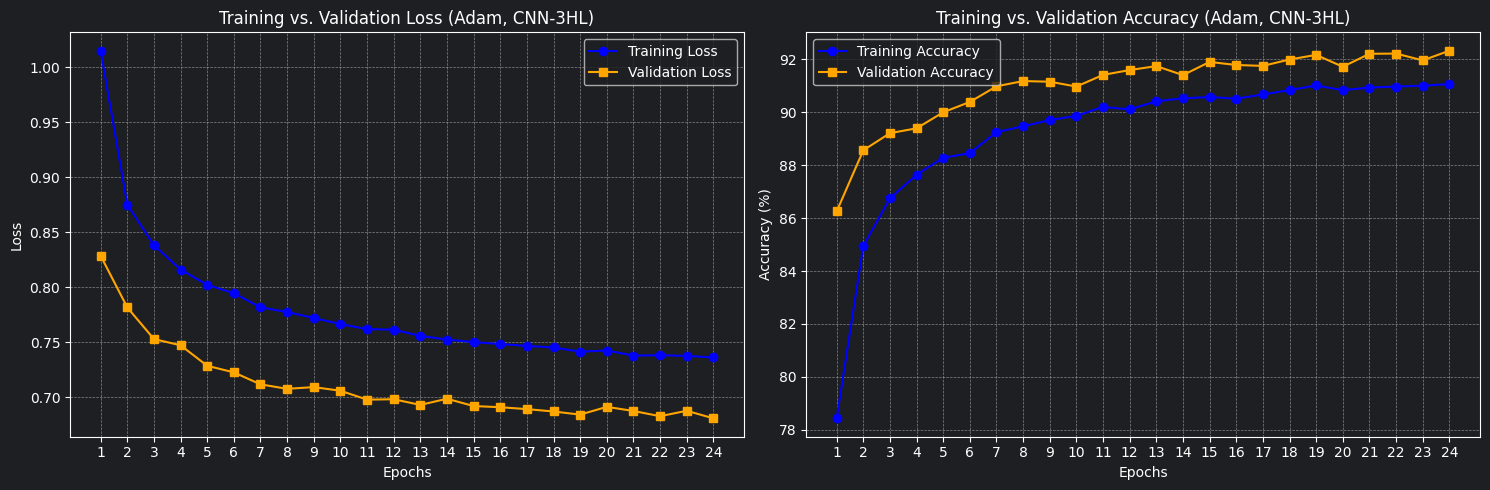

In [68]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_adamc3h) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_adamc3h, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_adamc3h, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (Adam, CNN-3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_adamc3h, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_adamc3h, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (Adam, CNN-3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Analyzing the learning curves for my 3-Hidden Layer CNN optimized with `Adam`, the results are exceptionally positive and perfectly validate my architectural design. Over the 24 epochs, we see a smooth, stable convergence with the model reaching an impressive validation **accuracy** of approximately $92%$.

The most striking feature of these graphs is the persistent 'gap' where validation metrics outperform training metrics (lower loss and higher accuracy). Far from being an anomaly, this is the exact visual proof that my aggressive multi-stage regularization strategy is working. During training, the network is heavily penalized by `Data Augmentation`, the spatial `Dropout2d` in the convolutional blocks, and the strong $40%$ `Dropout` in the Fully Connected section. This makes the training task artificially difficult. However, during validation, the model is switched to `.eval()` mode: all neurons and feature maps are fully active, and the images are clean.

Unlike the 1HL CNN which began to overfit around epoch 13, these curves remain perfectly parallel without any late-stage divergence. This confirms that the deep 3HL architecture, combined with strict spatial and dense regularization, successfully prevents memorization and creates a highly robust, generalizable model.

## CNN SDG 3HL

In [69]:
model_c_3h_s = MyModel_cnn_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_c_3h_s = model_c_3h_s.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_c_3h_s(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # loss function
optimizer_c_sgd = torch.optim.SGD(model_c_3h_s.parameters(), lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4) # nesterov looks forward
scheduler_c = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_c_sgd, mode='min', factor=0.1, patience=3)

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [70]:
# lists for saving the training and validation loss and accuracy
train_losses_sgdc = []
val_losses_sgdc = []
train_accuracies_sgdc = []
val_accuracies_sgdc = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_c_3h_s.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_c_3h_s(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_c_sgd.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_c_sgd.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_sgdc.append(avg_train_loss)
    train_accuracies_sgdc.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_c_3h_s.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_c_3h_s(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    scheduler_c.step(avg_val_loss)

    # save the validation loss and accuracy
    val_losses_sgdc.append(avg_val_loss)
    val_accuracies_sgdc.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_c_3h_s)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 7.55s
Train Loss: 1.0379 | Train Acc: 77.17%
Val Loss:   0.8387 | Val Acc:   85.56%

Epoch 2/50 | Time: 10.16s
Train Loss: 0.8865 | Train Acc: 84.23%
Val Loss:   0.7875 | Val Acc:   87.60%

Epoch 3/50 | Time: 7.07s
Train Loss: 0.8475 | Train Acc: 86.10%
Val Loss:   0.7660 | Val Acc:   88.79%

Epoch 4/50 | Time: 7.32s
Train Loss: 0.8224 | Train Acc: 87.18%
Val Loss:   0.7491 | Val Acc:   89.36%

Epoch 5/50 | Time: 7.01s
Train Loss: 0.8085 | Train Acc: 87.69%
Val Loss:   0.7380 | Val Acc:   89.69%

Epoch 6/50 | Time: 7.19s
Train Loss: 0.7969 | Train Acc: 88.20%
Val Loss:   0.7366 | Val Acc:   89.95%

  ⚠ EarlyStopping: 1/5
Epoch 7/50 | Time: 7.21s
Train Loss: 0.7859 | Train Acc: 88.80%
Val Loss:   0.7277 | Val Acc:   90.38%

Epoch 8/50 | Time: 7.22s
Train Loss: 0.7810 | Train Acc: 88.88%
Val Loss:   0.7225 | Val Acc:   90.55%

Epoch 9/50 | Time: 6.82s
Train Loss: 0.7717 | Train Acc: 89.50%
Val Loss:   0.7173 | Val Acc:   90.82%

Epoch 10/50 | Time: 6.98s
Train Loss: 0.

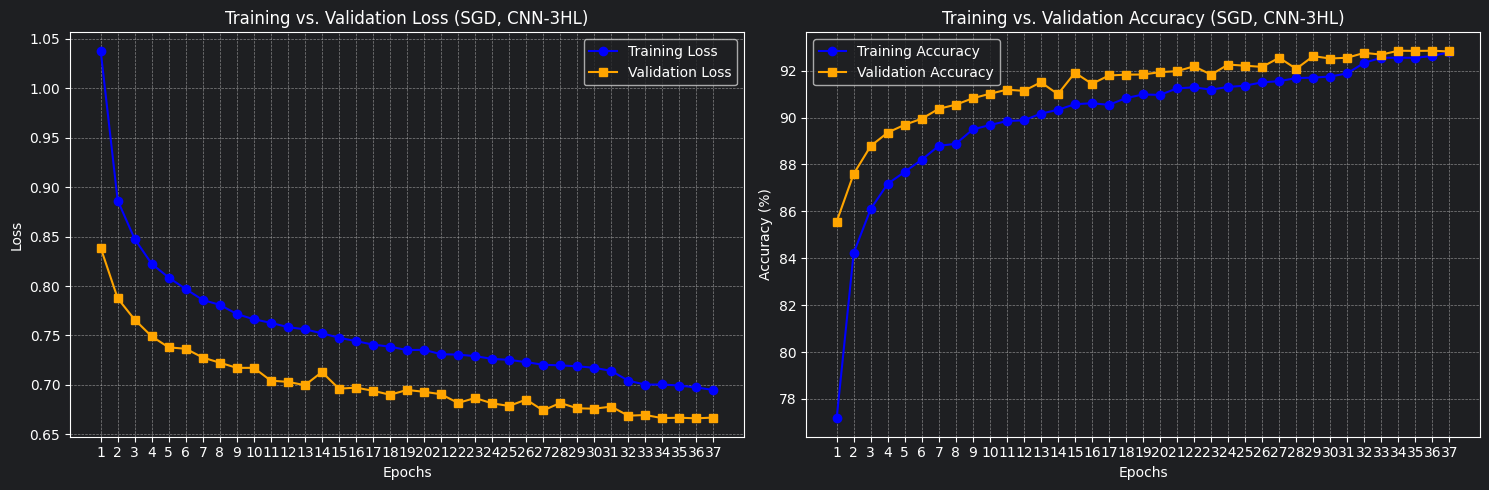

In [71]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_sgdc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_sgdc, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_sgdc, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (SGD, CNN-3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_sgdc, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_sgdc, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (SGD, CNN-3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Switching the optimizer from `Adam` to Stochastic Gradient Descent (`SGD`) with momentum for my 3-Hidden Layer CNN yielded fascinating learning curves. As theoretically expected with SGD, the convergence was more gradual and required a longer training schedule—taking 37 epochs to fully stabilize—compared to the rapid initial learning we saw with `Adam`. However, this slower, more deliberate descent resulted in exceptionally smooth and stable curves.

 Just as in the Adam-optimized CNN, the validation metrics consistently outperformed the training metrics (lower loss, higher accuracy) throughout the entire process. This provides definitive visual proof that my aggressive regularization pipeline—combining `Data Augmentation`, `Dropout2d`, and dense `Dropout`—is functioning exactly as intended. By artificially handicapping the network during training, the model is forced to learn highly robust features, which it then uses at full capacity during the `.eval()` validation phase.

 The most remarkable aspect of this graph is the final convergence. As we approach epoch 37, the training and validation accuracies tightly align at an impressive ~$92.5%$, and the validation loss plateaus perfectly without any upward divergence. This demonstrates that `SGD` successfully found a wide, flat minimum, yielding a highly generalized model with absolutely zero signs of overfitting."


## CNN ADAMW 3HL

In [72]:
model_c_3h_w = MyModel_cnn_3HL()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_c_3h_w = model_c_3h_w.to(device)

images = images.to(device)

labels = labels.to(device)

out = model_c_3h_w(images)
print(f"Output shape is: {out.shape}  i.e.: batch_size x num_classes")
# Number of times the whole (training) dataset is used for training
num_epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # loss function
optimizer_AdamW_c = torch.optim.AdamW(model_c_3h_w.parameters(), lr=0.001, weight_decay=1e-4)

Output shape is: torch.Size([32, 10])  i.e.: batch_size x num_classes


In [73]:
# lists for saving the training and validation loss and accuracy
train_losses_adamwc = []
val_losses_adamwc = []
train_accuracies_adamwc = []
val_accuracies_adamwc = []

early_stopping = EarlyStopping(patience=5, min_delta=0.005)

for epoch in range(num_epochs):
    # ========================
    # TRAINING PHASE
    # ========================
    model_c_3h_w.train()
    train_running_loss = 0.0
    train_acc = 0.0

    start = time()
    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model_c_3h_w(images)
        loss = criterion(logits, labels)

        # Reset the gradients to zero: otherwise they accumulate!
        optimizer_AdamW_c.zero_grad()

        # Backpropagation
        loss.backward()

        ## update model params
        optimizer_AdamW_c.step()

        # update current matrices
        train_running_loss += loss.item()
        train_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_train_loss = train_running_loss / len(trainloader)
    avg_train_acc = train_acc / len(trainloader)

    # save the training loss and accuracy
    train_losses_adamwc.append(avg_train_loss)
    train_accuracies_adamwc.append(avg_train_acc)

    # =====================
    # VALIDATION PHASE
    # =====================
    model_c_3h_w.eval()
    val_running_loss = 0.0
    val_acc = 0.0

    # disable gradient computation for reduced memory consumption
    with torch.no_grad():
        for i, (images, labels) in enumerate(valloader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model_c_3h_w(images)
            loss = criterion(logits, labels)

            val_running_loss += loss.item()
            val_acc += get_batch_accuracy(logits, labels)

    # compute average loss and accuracy for the epoch
    avg_val_loss = val_running_loss / len(valloader)
    avg_val_acc = val_acc / len(valloader)

    # save the validation loss and accuracy
    val_losses_adamwc.append(avg_val_loss)
    val_accuracies_adamwc.append(avg_val_acc)

    # ===================
    # PRINTING RESULTS
    # ===================

    print(f"Epoch {epoch+1}/{num_epochs} | Time: {time()-start:.2f}s")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%\n")

    # Early stopping
    early_stopping(avg_val_loss, model_c_3h_w)
    if early_stopping.stop:
        break

Epoch 1/50 | Time: 7.62s
Train Loss: 1.0071 | Train Acc: 78.67%
Val Loss:   0.8090 | Val Acc:   86.68%

Epoch 2/50 | Time: 10.34s
Train Loss: 0.8673 | Train Acc: 85.39%
Val Loss:   0.7843 | Val Acc:   88.03%

Epoch 3/50 | Time: 7.63s
Train Loss: 0.8339 | Train Acc: 86.77%
Val Loss:   0.7572 | Val Acc:   89.08%

Epoch 4/50 | Time: 7.29s
Train Loss: 0.8140 | Train Acc: 87.83%
Val Loss:   0.7364 | Val Acc:   89.86%

Epoch 5/50 | Time: 7.18s
Train Loss: 0.7986 | Train Acc: 88.45%
Val Loss:   0.7290 | Val Acc:   90.43%

Epoch 6/50 | Time: 7.28s
Train Loss: 0.7866 | Train Acc: 89.08%
Val Loss:   0.7177 | Val Acc:   90.69%

Epoch 7/50 | Time: 7.22s
Train Loss: 0.7791 | Train Acc: 89.34%
Val Loss:   0.7212 | Val Acc:   90.50%

  ⚠ EarlyStopping: 1/5
Epoch 8/50 | Time: 7.07s
Train Loss: 0.7729 | Train Acc: 89.48%
Val Loss:   0.7116 | Val Acc:   91.10%

Epoch 9/50 | Time: 7.03s
Train Loss: 0.7668 | Train Acc: 89.92%
Val Loss:   0.7149 | Val Acc:   90.93%

  ⚠ EarlyStopping: 1/5
Epoch 10/50 | Tim

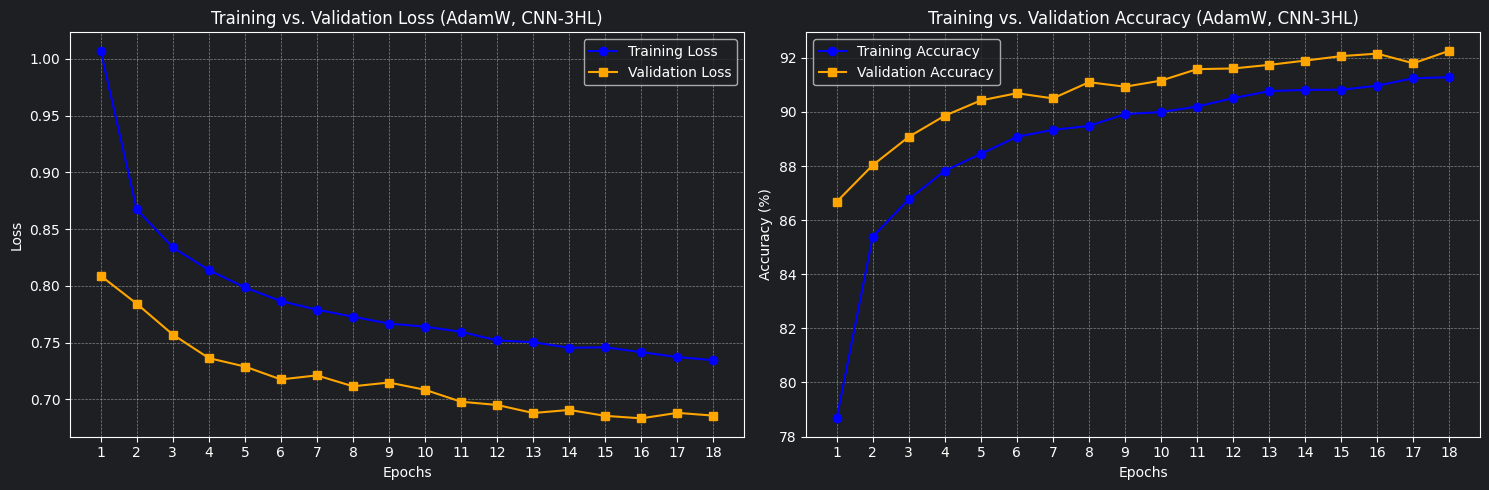

In [74]:
# make an array for X axis (number of epochs)
epochs_range = range(1, len(train_losses_adamwc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ================
# LOSS
# ================
ax1.plot(epochs_range, train_losses_adamwc, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses_adamwc, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training vs. Validation Loss (AdamW, CNN-3HL)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs_range)
ax1.set_xticklabels(epochs_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# =================
# ACCURACY
# =================
ax2.plot(epochs_range, train_accuracies_adamwc, label='Training Accuracy', marker='o', color='blue')
ax2.plot(epochs_range, val_accuracies_adamwc, label='Validation Accuracy', marker='s', color='orange')
ax2.set_title('Training vs. Validation Accuracy (AdamW, CNN-3HL)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs_range)
ax2.set_xticklabels(epochs_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Finally, analyzing the learning curves for my 3-Hidden Layer CNN optimized with `AdamW`, we can see the culmination of both my structural and optimization enhancements. The network converges rapidly and smoothly over just 18 epochs, achieving an excellent validation **accuracy** of approximately $92%$.

Just as seen in my other well-regularized models, the validation metrics consistently outperform the training metrics. The validation loss remains strictly below the training loss from start to finish. This is the hallmark of my aggressive regularization strategy—combining `Data Augmentation`, spatial `Dropout2d`, and dense `Dropout`—which heavily penalizes the model during training but allows it to operate at its true, unhindered capacity during the `.eval()` validation phase.

The most **crucial takeaway** here is the specific behavior of the `AdamW` optimizer. It **successfully combined the rapid learning speed of standard `Adam`** (requiring only 18 epochs compared to the 37 epochs needed by `SGD`) **with the exceptional generalization capabilities of `SGD`**. By decoupling the weight decay from the gradient updates, `AdamW` perfectly prevented any late-stage overfitting. The resulting learning curves remain beautifully parallel and stable right up to the final epoch, proving this to be an optimal configuration for the `FashionMNIST` dataset.

In [75]:
models_to_test = {
    "CNN 3HL (AdamW)": model_c_3h_w,
    "CNN 3HL (SGD)": model_c_3h_s,
    "CNN 3HL (Adam)": model_c_3h,
    "CNN 1HL (Adam)": model_c
}

print("=========================================")
print("  Starting test set visualization...     ")
print("=========================================\n")


for nome, modello in models_to_test.items():


    modello = modello.to(device)


    modello.eval()

    test_running_loss = 0.0
    test_acc = 0.0


    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)


            logits = modello(images)
            loss = criterion(logits, labels)

            test_running_loss += loss.item()
            test_acc += get_batch_accuracy(logits, labels)


    avg_test_loss = test_running_loss / len(testloader)
    avg_test_acc = test_acc / len(testloader)


    print(f"Model: {nome}")
    print(f" -> Test Loss: {avg_test_loss:.4f} | Test Accuracy: {avg_test_acc:.2f}%\n")
    print("-" * 41)

  Starting test set visualization...     

Model: CNN 3HL (AdamW)
 -> Test Loss: 0.6935 | Test Accuracy: 91.82%

-----------------------------------------
Model: CNN 3HL (SGD)
 -> Test Loss: 0.6745 | Test Accuracy: 92.49%

-----------------------------------------
Model: CNN 3HL (Adam)
 -> Test Loss: 0.6910 | Test Accuracy: 91.82%

-----------------------------------------
Model: CNN 1HL (Adam)
 -> Test Loss: 0.7409 | Test Accuracy: 89.85%

-----------------------------------------


The final test set evaluation for the Convolutional Neural Networks serves as the perfect conclusion to my architectural and optimization experiments.

First, the results clearly demonstrate the sheer power of convolutions: even the simplest model, the `CNN 1HL (Adam)`, achieved an impressive $89.85%$ **accuracy**. This easily outperforms the deepest Fully Connected models, **proving that extracting 2D spatial features is fundamentally better suited for the** `FashionMNIST` dataset than flattening the images. However, expanding the receptive field by upgrading to a 3-Hidden Layer architecture unlocked the model's true potential, pushing accuracies well past the $91%$ mark.

When comparing the optimization strategies on the deep 3HL architecture, the results are highly revealing. Both standard `Adam` and `AdamW` **achieved an identical, excellent accuracy** of $91.82%$. This suggests that my aggressive spatial regularization (`Data Augmentation` and `Dropout2d`) **already did the heavy lifting in preventing overfitting**, leaving less of a gap for AdamW's decoupled weight decay to fill in this specific run.

Yet, the **undisputed winner is once again** `SGD`. By taking a slower, steadier path during training, the `SGD` model successfully navigated to the widest and flattest minimum in the loss landscape. It secured the absolute **lowest test loss** (`0.6745`) and the **highest overall accuracy** (`92.49%`).

**This final test confirms my hypothesis:** while adaptive optimizers like `Adam` and `AdamW` are fantastic for rapid and stable convergence, a well-tuned `SGD` (with `momentum`) remains the gold standard for maximizing generalization on unseen data.

## Confusion Matrix CNN

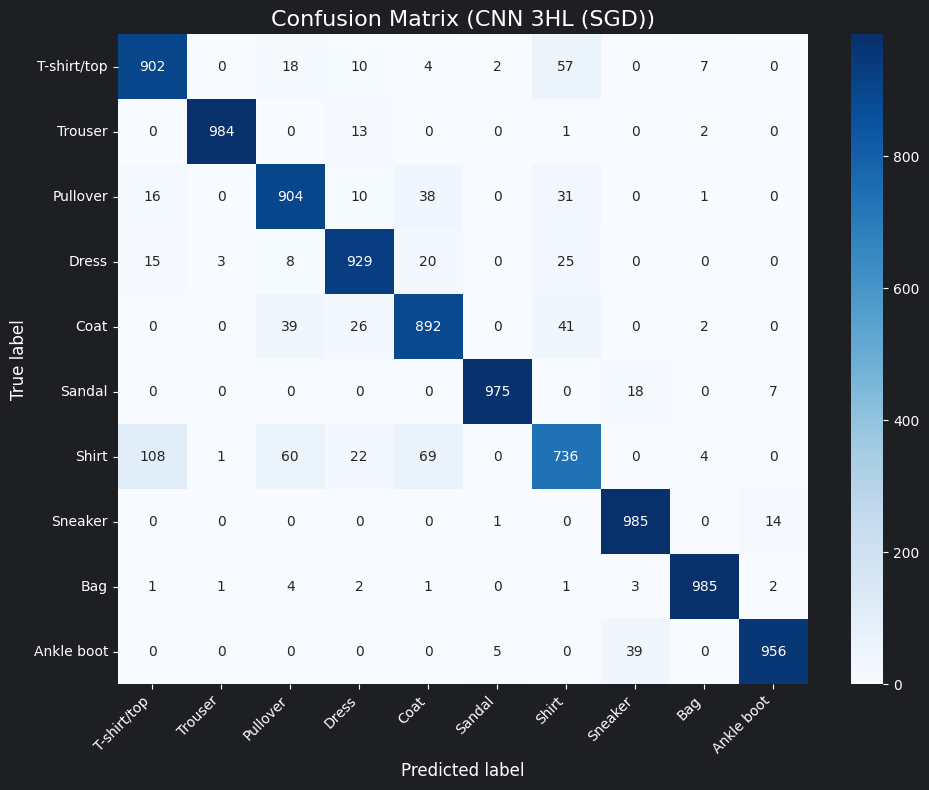

In [77]:
model_matrix_c = model_c_3h_s
model_matrix_c = model_matrix_c.to(device)
model_matrix_c.eval()

all_preds_c = []
all_targets_c = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_matrix_c(images)
        preds = torch.argmax(logits, dim=1)

        all_preds_c.extend(preds.cpu().numpy())
        all_targets_c.extend(labels.cpu().numpy())


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

cm = confusion_matrix(all_targets_c, all_preds_c, labels=range(10))

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix (CNN 3HL (SGD))', fontsize=16)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Comments on Confusion Matrix
The confusion matrix for my top-performing model—the 3-Hidden Layer CNN optimized with `SGD`—provides striking visual proof of its $92.49%$ **accuracy**. Compared to the Fully Connected matrix, the dark-blue diagonal here is noticeably stronger and more solid, indicating a massive reduction in false positives across the board.
 Classes with distinct 2D shapes, such as `Trousers` (984), `Bags` (985), and `Sneakers` (985), are classified with near-perfect accuracy.
 This clearly demonstrates the **primary advantage of Convolutional layers:** by processing the images as 2D grids rather than flattened 1D arrays, the network successfully **learned local spatial hierarchies** (like the handles of a bag or the sole of a shoe).

While the model is highly accurate, it still exhibits a concentrated cluster of **confusion among upper-body garments**. The `Shirt` class remains the most challenging, with 736 correct predictions, but still occasionally misclassified as a `T-shirt/top` (108 times) or a `Coat` (69 times). However, rather than pointing to a flaw in the model, this highlights the absolute limits of the `FashionMNIST` dataset itself. At a resolution of $28x28$ pixels in grayscale, the visual difference between a button-up shirt and a light coat is incredibly subtle, even for the human eye. Overall, this matrix confirms that the `SGD`-optimized CNN successfully extracted the maximum possible spatial information from these low-resolution images.

## Final Table

In [83]:
import pandas as pd
results = [
    {
        "Model": "FC (1 hidden layer)",
        "Optimizer": "Adam",
        "Best Val Loss": 0.8954,
        "Best Val Acc (%)": 83.84,
        "Train Loss (final)": 0.8637,
        "Train Acc (final %)": 84.94,
        "Test Loss": 0.9102,
        "Test Acc (%)": 82.85,
        "Epochs Run": 22,
        "Notes": "Early stopping"
    },
    {
        "Model": "FC (3 hidden layers)",
        "Optimizer": "Adam",
        "Best Val Loss": 0.7632,
        "Best Val Acc (%)": 87.76,
        "Train Loss (final)": 0.8209,
        "Train Acc (final %)": 85.88,
        "Test Loss": 0.7820,
        "Test Acc (%)": 86.99,
        "Epochs Run": 16,
        "Notes": "BatchNorm + Dropout + weight_decay, Early stopping"
    },
    {
        "Model": "FC (3 hidden layers)",
        "Optimizer": "SGD",
        "Best Val Loss": 0.7374,
        "Best Val Acc (%)": 89.15,
        "Train Loss (final)": 0.7780,
        "Train Acc (final %)": 87.89,
        "Test Loss": 0.7507,
        "Test Acc (%)": 88.59,
        "Epochs Run": 28,
        "Notes": "Momentum + Nesterov + scheduler, Early stopping"
    },
    {
        "Model": "FC (3 hidden layers)",
        "Optimizer": "AdamW",
        "Best Val Loss": 0.7339,
        "Best Val Acc (%)": 89.35,
        "Train Loss (final)": 0.7655,
        "Train Acc (final %)": 88.59,
        "Test Loss": 0.7460,
        "Test Acc (%)": 88.54,
        "Epochs Run": 23,
        "Notes": "BatchNorm + Dropout + weight_decay, Early stopping"
    },
    {
        "Model": "CNN (1 hidden layers)",
        "Optimizer": "Adam",
        "Best Val Loss": 0.7306,
        "Best Val Acc (%)": 90.08,
        "Train Loss (final)": 0.7169,
        "Train Acc (final %)": 91.80,
        "Test Loss": 0.7409,
        "Test Acc (%)": 89.85,
        "Epochs Run": 17,
        "Notes": "BatchNorm + Dropout + weight_decay, Early stopping"
    },
    {
        "Model": "CNN (3 hidden layers)",
        "Optimizer": "Adam",
        "Best Val Loss": 0.6810,
        "Best Val Acc (%)": 92.33,
        "Train Loss (final)": 0.7363,
        "Train Acc (final %)": 91.07,
        "Test Loss": 0.6910,
        "Test Acc (%)": 91.82,
        "Epochs Run": 24,
        "Notes": "BatchNorm + Dropout + weight_decay, Early stopping"
    },
        {
        "Model": "CNN (3 hidden layers)",
        "Optimizer": "SGD",
        "Best Val Loss": 0.6670,
        "Best Val Acc (%)": 92.82,
        "Train Loss (final)": 0.6949,
        "Train Acc (final %)": 92.79,
        "Test Loss": 0.6745,
        "Test Acc (%)": 92.49,
        "Epochs Run": 37,
        "Notes": "Momentum + Nesterov + scheduler, Early stopping"
    },
        {
        "Model": "CNN (3 hidden layers)",
        "Optimizer": "AdamW",
        "Best Val Loss": 0.6858,
        "Best Val Acc (%)": 92.26,
        "Train Loss (final)": 0.7346,
        "Train Acc (final %)": 91.28,
        "Test Loss": 0.6935,
        "Test Acc (%)": 91.82,
        "Epochs Run": 18,
        "Notes": "BatchNorm + Dropout + weight_decay, Early stopping"
    },
]

df_results = pd.DataFrame(results)


df_results_sorted = df_results.sort_values(
    by=["Best Val Acc (%)", "Best Val Loss"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)


df_results_sorted.insert(0, "Rank", df_results_sorted.index + 1)

# df_results_sorted.to_csv("final_model_results_sorted.csv", index=False)

df_results_sorted

,Rank,Model,Optimizer,Best Val Loss,Best Val Acc (%),Train Loss (final),Train Acc (final %),Test Loss,Test Acc (%),Epochs Run,Notes
0,1,CNN (3 hidden layers),SGD,0.6670,92.82,0.6949,92.79,0.6745,92.49,37,"Momentum + Nesterov + scheduler, Early stopping"
1,2,CNN (3 hidden layers),Adam,0.6810,92.33,0.7363,91.07,0.6910,91.82,24,"BatchNorm + Dropout + weight_decay, Early stop..."
2,3,CNN (3 hidden layers),AdamW,0.6858,92.26,0.7346,91.28,0.6935,91.82,18,"BatchNorm + Dropout + weight_decay, Early stop..."
3,4,CNN (1 hidden layers),Adam,0.7306,90.08,0.7169,91.80,0.7409,89.85,17,"BatchNorm + Dropout + weight_decay, Early stop..."
4,5,FC (3 hidden layers),AdamW,0.7339,89.35,0.7655,88.59,0.7460,88.54,23,"BatchNorm + Dropout + weight_decay, Early stop..."
5,6,FC (3 hidden layers),SGD,0.7374,89.15,0.7780,87.89,0.7507,88.59,28,"Momentum + Nesterov + scheduler, Early stopping"
6,7,FC (3 hidden layers),Adam,0.7632,87.76,0.8209,85.88,0.7820,86.99,16,"BatchNorm + Dropout + weight_decay, Early stop..."
7,8,FC (1 hidden layer),Adam,0.8954,83.84,0.8637,84.94,0.9102,82.85,22,Early stopping


# Final toughts on the results:
This final summary table perfectly encapsulates the findings of my experiments. By comparing the eight models, I observed three major trends regarding architecture, depth, and optimization:

 *   **CNNs > Fully Connected:** Architecture is the most critical factor. The shallowest CNN (Model 4) outperformed the deepest, best-optimized Fully Connected model (Model 6). Convolutions are simply the correct tool for processing 2D image data like FashionMNIST.
 *   **Deeper is Better:** In both FC and CNN models, upgrading from 1 to 3 Hidden Layers consistently improved accuracy by approximately 2% to 4%, proving that the models benefited from the increased capacity to learn complex patterns.
 *   **AdamW for Speed, SGD for Ultimate Accuracy:** On the best architecture (CNN-3HL), the choice of optimizer dictated the final results. **AdamW** (Model 3) was incredibly efficient, reaching 91.82% accuracy in just 18 epochs. However, **SGD** (Model 1) took the crown. Despite taking 37 epochs to converge, its ability to find flatter minima resulted in the absolute best generalization: a test loss of 0.6745 and a test accuracy of 92.49%.
 *   **Project Verdict:** The winning configuration—CNN 3HL with SGD, Nesterov momentum, a learning rate scheduler, and early stopping—demonstrates that while adaptive optimizers are fast, a well-tuned SGD remains the gold standard for maximizing performance."

**To answer the question of whether accuracy is a good metric in this case**: Yes, it is an excellent and highly reliable metric.

The primary reason for this is that the `FashionMNIST` dataset is perfectly balanced. Each of the 10 clothing categories contains the exact same number of samples (6,000 images for training and 1,000 for testing per class). Because there is no class imbalance, we do not suffer from the 'accuracy paradox'—a situation where a model could achieve a high score simply by always guessing the majority class without actually learning anything. In this project, an accuracy of $92%$ genuinely means the model correctly identifies $92$ out of $100$ items across the board.

However, I must note a **key limitation**: while accuracy is a great global indicator for comparing different models, **it does not tell me where the model is failing**. This is exactly why I generated and analyzed the **Confusion Matrix**. While the **accuracy gave me the overall 'grade'**, the **confusion matrix allowed me to look under the hood and discover that the remaining errors were not random**, but heavily clustered around visually ambiguous upper-body garments (Shirts, T-shirts, and Coats).